In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
import requests
from rdflib import Graph, URIRef, Literal, Namespace
import io
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from plotly_resampler import FigureResampler
import plotly.graph_objects as go
import joblib


In [3]:
#VIRTUOSO_URL = "http://localhost:8890/sparql-graph-crud"
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI = "http://example.com/Gent-Terneuzen"
USERNAME = "dba"
PASSWORD = "dba"
AUTH  = (USERNAME,PASSWORD)

In [4]:
params = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors

In [5]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT  DISTINCT ?sensor
    WHERE {{ 
        GRAPH <{GRAPH_URI}> {{ 
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }} 
    }} 
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
        print(f"Error: {res.status_code}")
        print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data = res.json()
bindings = data['results']['bindings']

for row in bindings:
    # Extract the URI string and add it to the set
    sensor_uri = row['sensor']['value']
    sensor_set.add(sensor_uri)

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)


Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289429042', 'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289441042'}


# Reframe the data 

In [6]:


# 1. Initialize an empty DataFrame for the master table
# We will start with just the 'time' column or an empty DF
final_df = pd.DataFrame()

print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    # Use the sensor URI (or just the ID part) as the column name
    column_name = sensor_uri.split('/')[-1] 
    
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{ 
            GRAPH <{GRAPH_URI}> {{ 
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }} 
        }} 
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        
        # 2. Create a temporary DF for THIS sensor
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']), 'unixtime': int(row['unixtime']['value'])} 
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            
            # 3. Merge this sensor into the final_df
            if final_df.empty:
                final_df = temp_df
            else:
                # 'outer' join ensures we keep timestamps even if some sensors are missing data
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')

            
            print(f"Added column for sensor: {column_name}")

# 4. Final touches
final_df = final_df.sort_values('time').set_index('time')

print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289435042
Added column for sensor: 289429042
Added column for sensor: 289423042
Added column for sensor: 289441042
Finished!
                           289435042    unixtime  289429042  289423042  \
time                                                                     
2021-03-03 23:15:00+00:00    3606.54  1614813300    1605.77        NaN   
2021-03-03 23:30:00+00:00        NaN  1614814200        NaN        NaN   
2021-03-03 23:45:00+00:00    3556.45  1614815100    1602.34     902.27   
2021-03-04 00:00:00+00:00        NaN  1614816000    1611.26        NaN   
2021-03-04 00:15:00+00:00        NaN  1614816900    1614.24     901.96   

                           289441042  
time                                  
2021-03-03 23:15:00+00:00    4797.72  
2021-03-03 23:30:00+00:00    4717.80  
2021-03-03 23:45:00+00:00    4745.36  
2021-03-04 00:00:00+00:00        NaN  
2021-03-04 00:15:00+00:00        NaN  


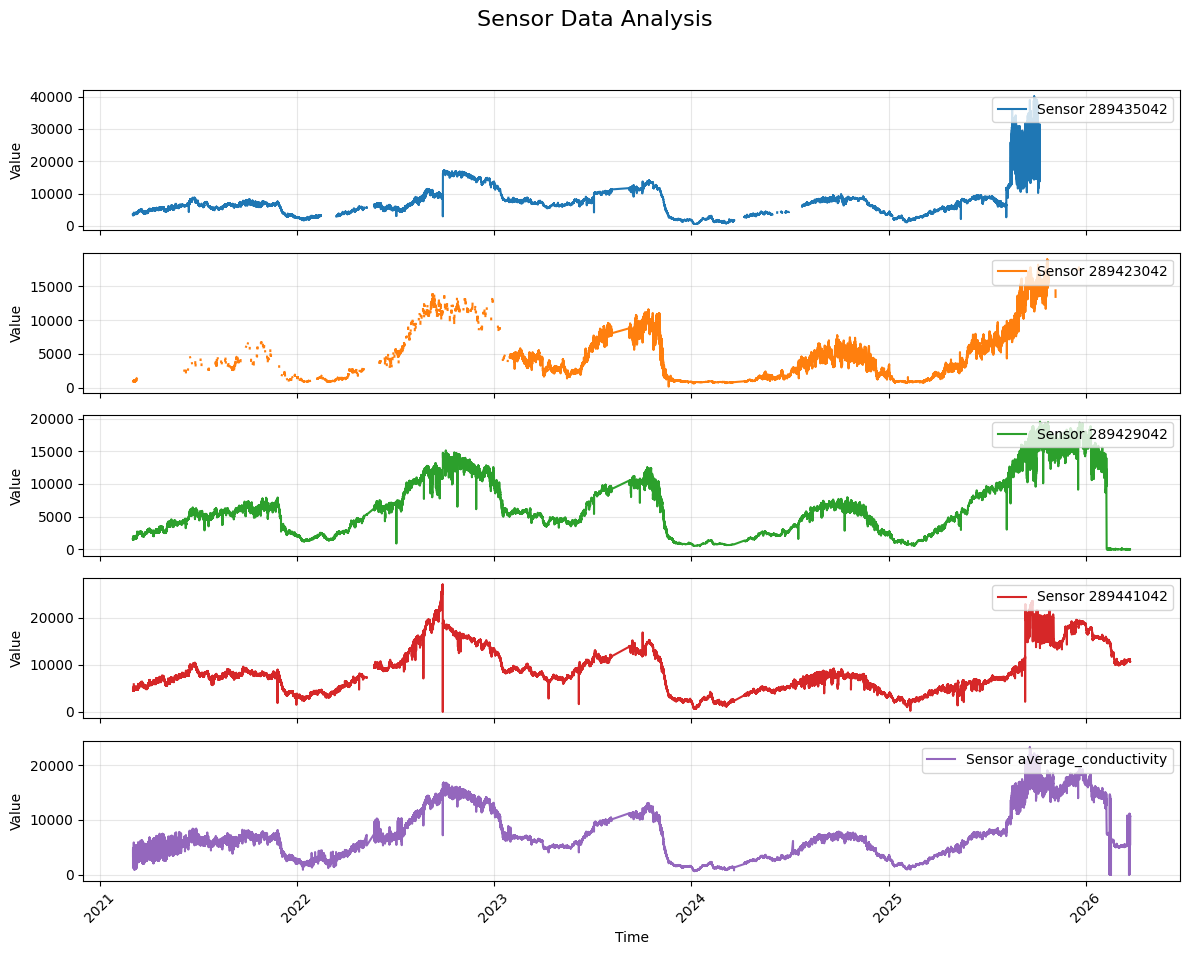

In [7]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#9467bd']
final_df['average_conductivity'] = final_df[sensors].mean(axis=1)
sensors_with_avg = sensors + ['average_conductivity']

for i, sensor in enumerate(sensors_with_avg):
    ax = axes[i]
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [8]:
df_clean = final_df.copy()
df_clean = df_clean.ffill().bfill()

sensors = ['289435042', '289423042', '289429042', '289441042']

# Use only the average of all sensors as the single univariate series.
# Multiple sensors measuring the same attribute at the same timestamps are
# largely redundant for forecasting; averaging them reduces per-sensor noise
# and gives a cleaner, single signal.
df_clean['average_conductivity'] = df_clean[sensors].mean(axis=1)

series = df_clean['average_conductivity'].values.reshape(-1, 1)  # (n_samples, 1)
target_col_idx = 0   # only one column

# Split FIRST, then scale — prevents data leakage
split_index  = int(len(series) * 0.8)
train_data   = series[:split_index]
test_data    = series[split_index:]

scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)   # (n_train, 1)
test_scaled  = scaler.transform(test_data)         # (n_test,  1)

print(f"Train samples: {len(train_scaled):,}  |  Test samples: {len(test_scaled):,}")

Train samples: 134,873  |  Test samples: 33,719


In [ ]:
time_steps = 672   # 1 week of 15-min readings
n_future   = 288    # 3 days ahead
stride     = n_future  # non-overlapping windows

def create_sequences_univariate(dataset, time_steps, n_future, stride):
    """
    dataset : (n_samples, 1) scaled array
    Returns
      X : (samples, time_steps, 1)  — 3-D, ready for LSTM
      y : (samples, n_future)       — future horizon to predict
    """
    X, y = [], []
    for i in range(0, len(dataset) - time_steps - n_future + 1, stride):
        X.append(dataset[i : i + time_steps, :])          # (time_steps, 1)
        y.append(dataset[i + time_steps : i + time_steps + n_future, 0])  # (n_future,)
    return np.array(X), np.array(y)

X_train, y_train = create_sequences_univariate(train_scaled, time_steps, n_future, stride)
X_test,  y_test  = create_sequences_univariate(test_scaled,  time_steps, n_future, stride)

print(f"X_train: {X_train.shape}  →  (samples, time_steps, 1)")
print(f"y_train: {y_train.shape}  →  (samples, n_future)")

X_train: (5591, 672, 1)  →  (samples, time_steps, 1)
y_train: (5591, 24)  →  (samples, n_future)


In [10]:
# ── LSTM Autoencoder ──────────────────────────────────────────────────────────
# The encoder compresses the 672-step sequence into a 16-dim bottleneck vector.
# The decoder reconstructs the original sequence from that vector.
# This forces the bottleneck to learn a meaningful temporal representation
# before the forecast head is attached.

def build_lstm_autoencoder(time_steps, n_features=1):
    inputs = layers.Input(shape=(time_steps, n_features), name='encoder_input')

    # ── Encoder ──────────────────────────────────────────────────────────────
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.LSTM(32, return_sequences=False)(x)   # collapses time dimension
    bottleneck = layers.Dense(16, name='bottleneck')(x)

    # ── Decoder ──────────────────────────────────────────────────────────────
    x = layers.RepeatVector(time_steps)(bottleneck)   # re-expands time dimension
    x = layers.LSTM(32, return_sequences=True)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    outputs = layers.TimeDistributed(layers.Dense(n_features), name='reconstruction')(x)

    autoencoder = Model(inputs, outputs, name='lstm_autoencoder')
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return autoencoder


autoencoder = build_lstm_autoencoder(time_steps=time_steps, n_features=1)
autoencoder.summary()

# ── Stage 1: pre-train on reconstruction ──────────────────────────────────────
autoencoder.fit(
    X_train, X_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ── Stage 2: extract encoder, freeze weights, attach forecast head ─────────────
encoder = Model(
    inputs  = autoencoder.input,
    outputs = autoencoder.get_layer('bottleneck').output,
    name    = 'encoder'
)
for layer in encoder.layers:
    layer.trainable = False

forecast_input  = layers.Input(shape=(time_steps, 1), name='forecast_input')
z               = encoder(forecast_input)          # (batch, 16)
forecast_output = layers.Dense(n_future)(z)        # (batch, 96)

forecaster = Model(forecast_input, forecast_output, name='forecaster')
forecaster.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
forecaster.summary()

forecaster.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ── Stage 3: unfreeze encoder, fine-tune end-to-end with low LR ───────────────
for layer in encoder.layers:
    layer.trainable = True

forecaster.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='mse')
forecaster.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 672, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 672, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 672, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 672, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 672, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 672, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 672, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 672, 1)         │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,009 (238.32 KB)

 Trainable params: 61,009 (238.32 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ forecast_input (InputLayer)     │ (None, 672, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 16)             │        29,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,248 (118.16 KB)

 Trainable params: 408 (1.59 KB)

 Non-trainable params: 29,840 (116.56 KB)

Epoch 1/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 30s 182ms/step - loss: 0.1063 - val_loss: 0.0103
Epoch 2/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - loss: 0.0172 - val_loss: 0.0025
Epoch 3/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - loss: 0.0064 - val_loss: 0.0026
Epoch 4/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - loss: 0.0041 - val_loss: 0.0035
Epoch 5/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - loss: 0.0034 - val_loss: 0.0039
Epoch 6/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - loss: 0.0031 - val_loss: 0.0038
Epoch 7/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - loss: 0.0029 - val_loss: 0.0036
Epoch 8/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - loss: 0.0027 - val_loss: 0.0034
Epoch 9/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 27s 169ms/step - loss: 0.0026 - val_loss: 0.0031
Epoch 10/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 26s 162ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 11/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 27s 171ms/step - loss: 0.0024 - val_loss: 0.0029
Epoch 12/30
158/158

In [ ]:
full_scaled   = np.concatenate([train_scaled, test_scaled], axis=0)  # (n_total, 1) last 672 timesteps of all available data and feeds it into the model to predict the next 24 steps into the future
last_sequence = full_scaled[-time_steps:]                               # (time_steps, 1)
last_sequence = last_sequence.reshape(1, time_steps, 1)                # (1, time_steps, 1)

scaled_forecast = forecaster.predict(last_sequence)                     # (1, n_future)

forecast_real = scaler.inverse_transform(
    scaled_forecast[0].reshape(-1, 1)
).flatten()

print(f"Forecast for the next {n_future} steps (average conductivity):")
for i, val in enumerate(forecast_real, 1):
    print(f"  t+{i:2d}: {val:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
Forecast for the next 24 steps (average conductivity):
  t+ 1: 11348.6328
  t+ 2: 11297.8105
  t+ 3: 11255.9062
  t+ 4: 11348.3496
  t+ 5: 11169.3818
  t+ 6: 11332.1924
  t+ 7: 11151.4668
  t+ 8: 11294.6260
  t+ 9: 11211.0889
  t+10: 11278.8428
  t+11: 11191.5820
  t+12: 11155.0361
  t+13: 11341.5469
  t+14: 11248.6582
  t+15: 11304.4971
  t+16: 11111.6133
  t+17: 11379.7461
  t+18: 11359.6484
  t+19: 11361.4775
  t+20: 11203.8330
  t+21: 11507.5273
  t+22: 11367.7002
  t+23: 11405.4238
  t+24: 11305.8936


In [ ]:
test_preds_scaled = forecaster.predict(X_test)   # (samples, n_future)  runs the model on the entire test set and computes MAE and RMSE for each of the 24 forecast steps individually
# accuracy degrades the further ahead we predict
print(f"{'Step':<8} {'MAE':>8} {'RMSE':>8}")
print("-" * 26)

for step in range(n_future):
    preds_real = scaler.inverse_transform(
        test_preds_scaled[:, step].reshape(-1, 1)
    ).flatten()
    true_real = scaler.inverse_transform(
        y_test[:, step].reshape(-1, 1)
    ).flatten()

    mae  = mean_absolute_error(true_real, preds_real)
    rmse = np.sqrt(mean_squared_error(true_real, preds_real))
    print(f"  t+{step+1:<4}  {mae:>7.4f}  {rmse:>7.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step
Step          MAE     RMSE
--------------------------
  t+1     405.1255  814.8800
  t+2     426.4541  706.3535
  t+3     357.7684  729.5274
  t+4     467.5250  938.4114
  t+5     806.0133  1497.2514
  t+6     717.5922  1319.7115
  t+7     722.0027  1367.9301
  t+8     500.5318  972.8565
  t+9     648.2661  1207.5105
  t+10    594.1765  1120.8228
  t+11    645.8493  1237.8096
  t+12    592.2500  1135.9133
  t+13    604.1819  1082.1410
  t+14    770.3036  1364.3314
  t+15    832.8718  1499.8773
  t+16    617.2808  1153.4166
  t+17    788.9858  1365.9363
  t+18    415.0387  723.4967
  t+19    701.0993  1261.1247
  t+20    808.9472  1430.9328
  t+21    411.6542  728.8840
  t+22    413.8536  802.2188
  t+23    514.1335  914.7788
  t+24    765.6036  1317.1025


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


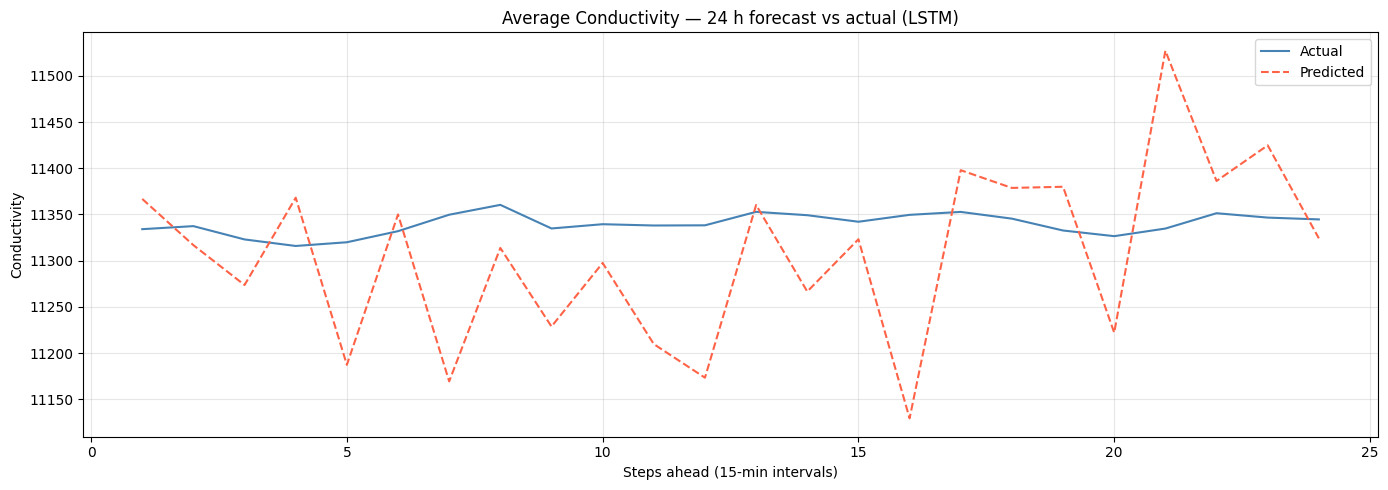

In [13]:
last_pred_scaled = forecaster.predict(X_test[-1:])   # (1, n_future)

pred_real = scaler.inverse_transform(last_pred_scaled[0].reshape(-1, 1)).flatten()
true_real = scaler.inverse_transform(y_test[-1].reshape(-1, 1)).flatten()

steps = range(1, n_future + 1)
plt.figure(figsize=(14, 5))
plt.plot(steps, true_real,  label='Actual',    color='steelblue', linewidth=1.5)
plt.plot(steps, pred_real,  label='Predicted', color='tomato',    linewidth=1.5, linestyle='--')
plt.title('Average Conductivity — 24 h forecast vs actual (LSTM)')
plt.xlabel('Steps ahead (15-min intervals)')
plt.ylabel('Conductivity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Saving model info

In [15]:
forecaster.save("./modeldump/forecaster.keras")
autoencoder.save("./modeldump/autoencoder.keras")
joblib.dump(scaler, "./modeldump/scaler.pkl")


['./modeldump/scaler.pkl']

# loading model

In [ ]:
from tensorflow.keras.models import load_model
import joblib

forecaster = load_model("./modeldump/forecaster.keras")
scaler = joblib.load("scaler.pkl") #Without saving the scaler, loaded model will produce scaled outputs you can't convert back to real conductivity values.